# DQN-only Evaluation

In [1]:
import sys
import os
import torch
import pandas as pd

if 'google.colab' in sys.modules:
  from google.colab import drive
  drive.mount( "/content/drive")
  if os.path.isdir('drive/MyDrive/Projects/Offline_RL_BSc_Thesis/notebooks/DQN/DQN_only'):
    os.chdir('drive/MyDrive/Projects/Offline_RL_BSc_Thesis/notebooks/DQN/DQN_only')


project_root = os.path.abspath(os.path.join(os.path.dirname("__file__"), "../../../../"))
if project_root not in sys.path:
    sys.path.append(project_root)

torch_device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')

## Evaluation in the Live Environment for 1000 episodes

In [2]:
import yaml
import warnings

from src.utils.live_env_testing import DQN_BC_evaluate_model_in_live_env

warnings.filterwarnings("ignore")
with open('../../../config/DQN/DQN_only/dqn_only_live_env_elavuation_config.yaml', 'r') as f:
    dqn_only_live_env_config_config = yaml.safe_load(f)

norm_names = ['raw', 'max_abs', 'min_max', 'robust', 'standard']

C:\Users\Miro\AppData\Local\Programs\Python\Python313\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Replay Buffer

In [3]:
rb_rewards_dict = {}

for rb_norm_name in norm_names:
    print('-'*100)
    print('Normalization:', rb_norm_name)

    if rb_norm_name != 'raw':
        rb_normalization_technique = torch.jit.load(f'../../../models/BC/replay_buffer/normalization/{rb_norm_name}_normalization.pt')
    else:
        rb_normalization_technique = None
    rb_model = torch.jit.load(f'../../../models/DQN/replay_buffer/DQN_only_{rb_norm_name}.pt')

    rb_rewards = DQN_BC_evaluate_model_in_live_env(
        env_test_params=dqn_only_live_env_config_config,
        model_name='replay_buffer',
        model_variant_name=rb_norm_name,
        norm_technique=rb_normalization_technique,
        model_theta_variant='DQN_only',
        model = rb_model,
    )
    rb_rewards_dict[f'{rb_norm_name}_reward'] = rb_rewards

----------------------------------------------------------------------------------------------------
Normalization: raw


100%|██████████| 1000/1000 [04:41<00:00,  3.55it/s]


----------------------------------------------------------------------------------------------------
Normalization: max_abs


100%|██████████| 1000/1000 [03:36<00:00,  4.62it/s]


----------------------------------------------------------------------------------------------------
Normalization: min_max


100%|██████████| 1000/1000 [00:46<00:00, 21.36it/s]


----------------------------------------------------------------------------------------------------
Normalization: robust


100%|██████████| 1000/1000 [03:48<00:00,  4.37it/s]


----------------------------------------------------------------------------------------------------
Normalization: standard


100%|██████████| 1000/1000 [05:38<00:00,  2.96it/s]


### Final Policy

In [4]:
fp_rewards_dict = {}

for fp_norm_name in norm_names:
    print('-'*100)
    print('Normalization:', fp_norm_name)


    if fp_norm_name != 'raw':
        fp_normalization_technique = torch.jit.load(f'../../../models/BC/final_policy/normalization/{fp_norm_name}_normalization.pt')
    else:
        fp_normalization_technique = None
    fp_model = torch.jit.load(f'../../../models/DQN/final_policy/DQN_only_{fp_norm_name}.pt')

    fp_rewards = DQN_BC_evaluate_model_in_live_env(
        env_test_params=dqn_only_live_env_config_config,
        model_name='final_policy',
        model_variant_name=fp_norm_name,
        norm_technique=fp_normalization_technique,
        model_theta_variant='DQN_only',
        model = fp_model
    )
    fp_rewards_dict[f'{fp_norm_name}_reward'] = fp_rewards

----------------------------------------------------------------------------------------------------
Normalization: raw


100%|██████████| 1000/1000 [00:35<00:00, 28.14it/s]


----------------------------------------------------------------------------------------------------
Normalization: max_abs


100%|██████████| 1000/1000 [01:15<00:00, 13.28it/s]


----------------------------------------------------------------------------------------------------
Normalization: min_max


100%|██████████| 1000/1000 [01:20<00:00, 12.49it/s]


----------------------------------------------------------------------------------------------------
Normalization: robust


100%|██████████| 1000/1000 [01:06<00:00, 15.05it/s]


----------------------------------------------------------------------------------------------------
Normalization: standard


100%|██████████| 1000/1000 [00:50<00:00, 19.77it/s]


### Accumulated rewards distribution comparison

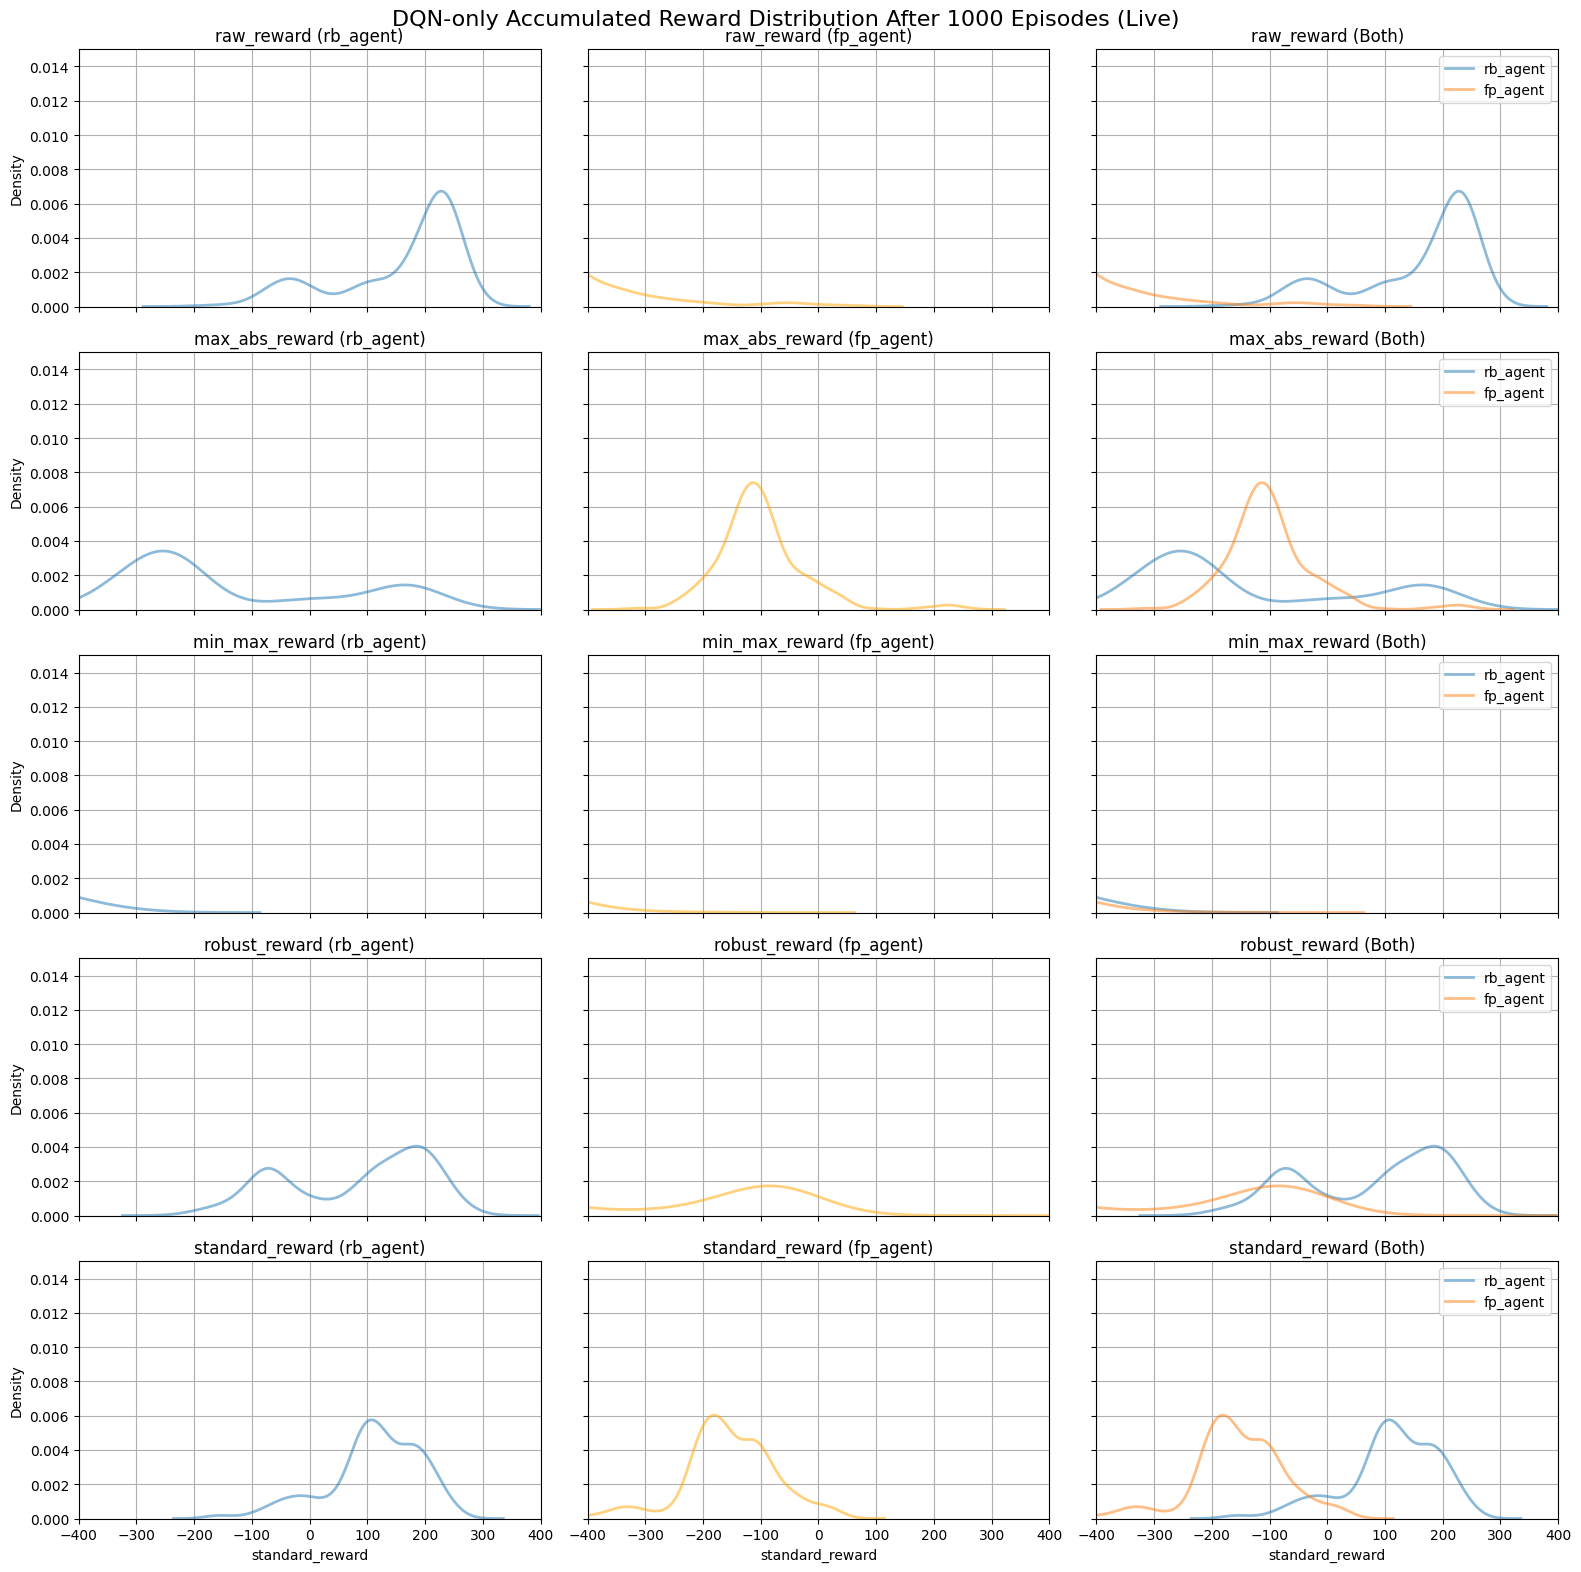

In [5]:
from src.utils.plotting import plot_univariate_analysis


rb_rewards_df = pd.DataFrame(rb_rewards_dict)
fp_rewards_df = pd.DataFrame(fp_rewards_dict)

rb_fp_combined_fig = plot_univariate_analysis(
        df1_name = 'rb_agent',
        df2_name = 'fp_agent',
        df1=rb_rewards_df,
        df2=fp_rewards_df,
        num_columns=3,
        custom_title='DQN-only Accumulated Reward Distribution After 1000 Episodes (Live)',
        kde_kwargs={'linewidth': 2, 'alpha': 0.5},
        f_size=(16,16),
        sharex=True,
        sharey=True,
        xlim=(-400, 400),
        ylim=(0, 0.015)
)
rb_fp_combined_fig.savefig('../../../plots/DQN_only_liven_env_1000_ep_eval_rb_fp.jpg')